# Time series data and models

## Model estimation and identification

- Fernando Corcuera and Diego the cat 


**The right model?**

- It is hard to model real world data and make inferences about it, the models rarely fits
- It always requrie judgement and evaluation not just computing stats and trying 1000 different models
- With monte carlo simulations we have a really intersting laboratory where we can test different identification test
- The process is :

1. Given a model, estimate its parameters
2. Given a set of models, determine the best


In [59]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

## Order determination: AR(2) example

- Autocorrelation: measures the total correlation between observations of different lags
- Partial autocorrelation: measures direct correlation between observations after removing the effect of intermidiate lags 

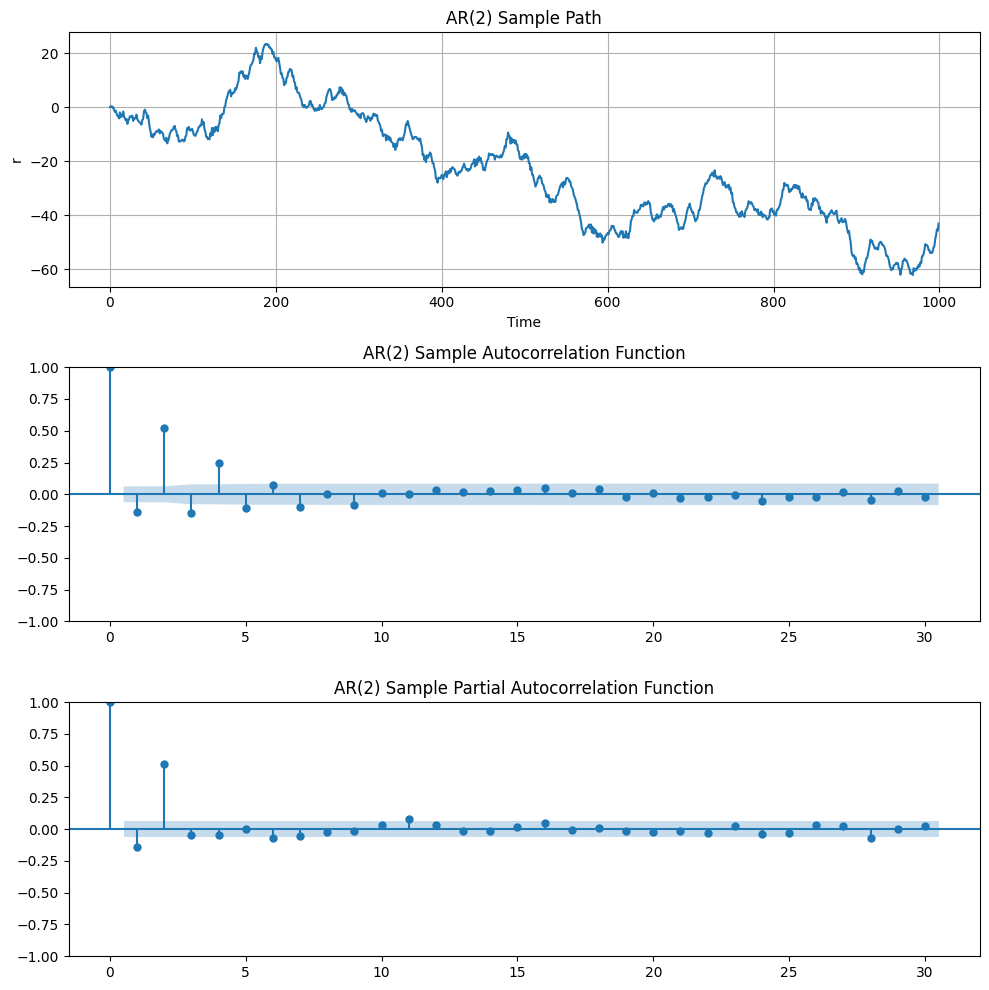

In [60]:
c_0 = 0.001
c_1 = -0.1
c_2 = 0.5
sigma = 1
Nt = 1000
r = np.zeros(shape=Nt)
z = np.random.normal(size=Nt)

for i in range(2, Nt):

    r[i] = c_0 + c_1 * r[i - 1] + c_2 * r[i - 2] + sigma * z[i]

sample_path = np.cumsum(r)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10))

# AR PROCESS
axes[0].plot(sample_path)
axes[0].set_title("AR(2) Sample Path")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("r")
axes[0].grid(True)

# ACF
plot_acf(r, lags=30, ax=axes[1])
axes[1].set_title("AR(2) Sample Autocorrelation Function")

# PACF
plot_pacf(r, lags=30, ax=axes[2], method="ywm")

axes[2].set_title("AR(2) Sample Partial Autocorrelation Function")

plt.tight_layout()

plt.show()

## Model estimation AR(2) example:

- Autoregresive models can be viewed as linear regression models where the X features are the Y features lagged by n periods!
- For the process to be consistent, the regression residuals must be (approximately) an independent, uncorrelated white noise process.
- Overall a good time-series model should explain all predictable structure in the data. Therefore, the residuals should behave like white noise. If residuals remain autocorrelated, then the model has not captured all the information contained in past observations.

In [61]:
y = r[2:]
x1 = r[1:-1]
x2 = r[:-2]

X = pd.DataFrame({"x1": x1, "x2": x2})

X = sm.add_constant(X)
AR2model = sm.OLS(y, X).fit()
print(AR2model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     194.1
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           6.62e-72
Time:                        08:48:42   Log-Likelihood:                -1450.8
No. Observations:                 998   AIC:                             2908.
Df Residuals:                     995   BIC:                             2922.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0230      0.033     -0.700      0.4

- Note how the linear regression has found similar coefficients (estimators) of the ar(2) process!
- **std err**: How much would the estimate vary if we repeated the simulation many times?
- **t-statistic** : How many standard errors away from zero is the stimate?
- **P-value**: <0.5 -> strong evidence that the coefficient is different than zero
- **Confidence interval**: A 95% confidence interval for the true coefficient.
- **R-squared**: 30% of the variation in r_t is explained by lagged returns
- **F-statistic**: Null hypothesis than both coefficents are 0
- **Durbin-Watson**: 2 -> no autocorrelation, <2 -> positive autocorrealtion, ...
- **jaque vera**: H0 that residuals are normal (0.76 no evidence against normality)

In [62]:
model = ARIMA(r, order=(2, 0, 0))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1453.033
Date:                Tue, 23 Jun 2026   AIC                           2914.067
Time:                        08:48:43   BIC                           2933.698
Sample:                             0   HQIC                          2921.528
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0414      0.059     -0.701      0.484      -0.157       0.074
ar.L1         -0.0696      0.028     -2.507      0.012      -0.124      -0.015
ar.L2          0.5157      0.027     18.806      0.0

In [63]:
print("True parameters")
print(c_0, c_1, c_2)
print("AR(2) model: ")
print(AR2model.params)
print("ARIMA(2,0,0) model: ")
print(results.params)

True parameters
0.001 -0.1 0.5
AR(2) model: 
const   -0.023016
x1      -0.069650
x2       0.516688
dtype: float64
ARIMA(2,0,0) model: 
[-0.04140705 -0.06957352  0.51565631  1.06987403]


In [64]:
# what would happen if we fail to identify the process?
bad_model = ARIMA(r, order=(5, 0, 0))
bad_results = bad_model.fit()

print(bad_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -1450.933
Date:                Tue, 23 Jun 2026   AIC                           2915.867
Time:                        08:48:46   BIC                           2950.221
Sample:                             0   HQIC                          2928.924
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0422      0.054     -0.777      0.437      -0.148       0.064
ar.L1         -0.0470      0.032     -1.466      0.143      -0.110       0.016
ar.L2          0.5348      0.032     16.905      0.0

## Order determination: MA(2) Example

In [65]:
mu = 0
sigma = 1.1
phi_1 = -0.1
phi_2 = 0.4
Nt = 1000
r = np.zeros(shape=Nt)
z = np.random.normal(size=Nt)

r[0] = mu + sigma * z[0]
r[1] = mu + sigma * z[1] + phi_1 * z[0]

r[2:] = mu + sigma * z[2:] + phi_1 * z[1:-1] + phi_2 * z[:-2]

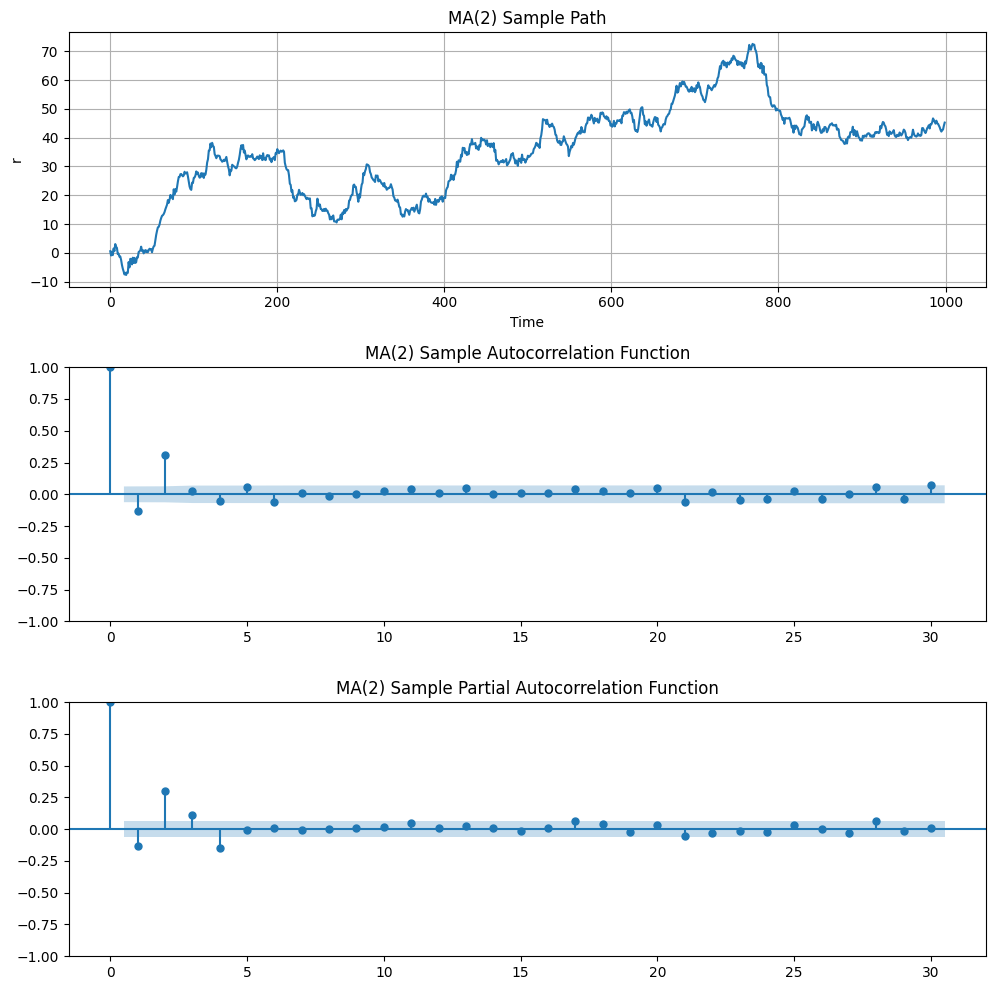

In [66]:
sample_path = np.cumsum(r)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10))

# MAPROCESS
axes[0].plot(sample_path)
axes[0].set_title("MA(2) Sample Path")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("r")
axes[0].grid(True)

# ACF
plot_acf(r, lags=30, ax=axes[1])
axes[1].set_title("MA(2) Sample Autocorrelation Function")

# PACF
plot_pacf(r, lags=30, ax=axes[2], method="ywm")

axes[2].set_title("MA(2) Sample Partial Autocorrelation Function")

plt.tight_layout()

plt.show()

## Model estimation MA(2):

In [67]:
MA2 = ARIMA(r, order=(0, 0, 2))
MA2_results = MA2.fit()

print(MA2_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1526.209
Date:                Tue, 23 Jun 2026   AIC                           3060.419
Time:                        08:48:50   BIC                           3080.050
Sample:                             0   HQIC                          3067.880
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0455      0.044      1.022      0.307      -0.042       0.133
ma.L1         -0.1104      0.029     -3.793      0.000      -0.167      -0.053
ma.L2          0.3749      0.029     13.115      0.0

# Real data is much harder: TSMC

In [69]:
ticker = "TSM"
start_date = "1999-12-31"
end_date = "2025-12-31"

tsm = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,  # if true yahoo automtically modifies the open/close/low prices using adjustemnt factors
)
tsm.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSM,TSM,TSM,TSM,TSM,TSM
Date,,,,,,
1999-12-31,8.424754,17.059277,17.154051,16.798651,16.846037,428125
2000-01-03,8.869394,17.959627,18.007015,17.462067,17.912241,2062807
2000-01-04,8.927898,18.078094,18.670431,17.912241,17.959627,2557142
2000-01-05,8.986407,18.196564,18.362417,18.078094,18.243950,2295467
2000-01-06,8.611970,17.438372,17.793774,17.059277,17.770081,1539456


<Figure size 1000x500 with 0 Axes>

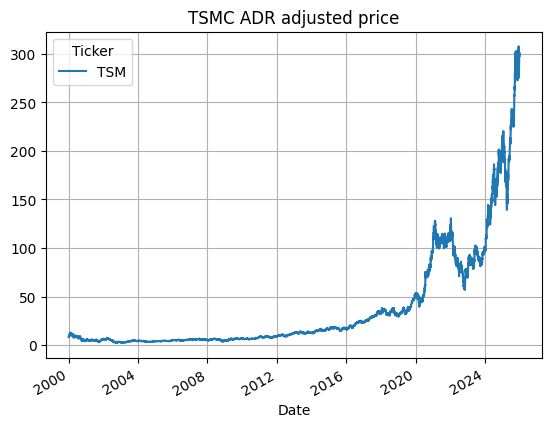

In [ ]:
adj_prices = tsm["Adj Close"].dropna()
# this is how prices look over time, we can obersrve the AI boom int he last years
plt.figure(figsize=(10, 5))
adj_prices.plot(title="TSMC ADR adjusted price")
plt.grid()
plt.show()

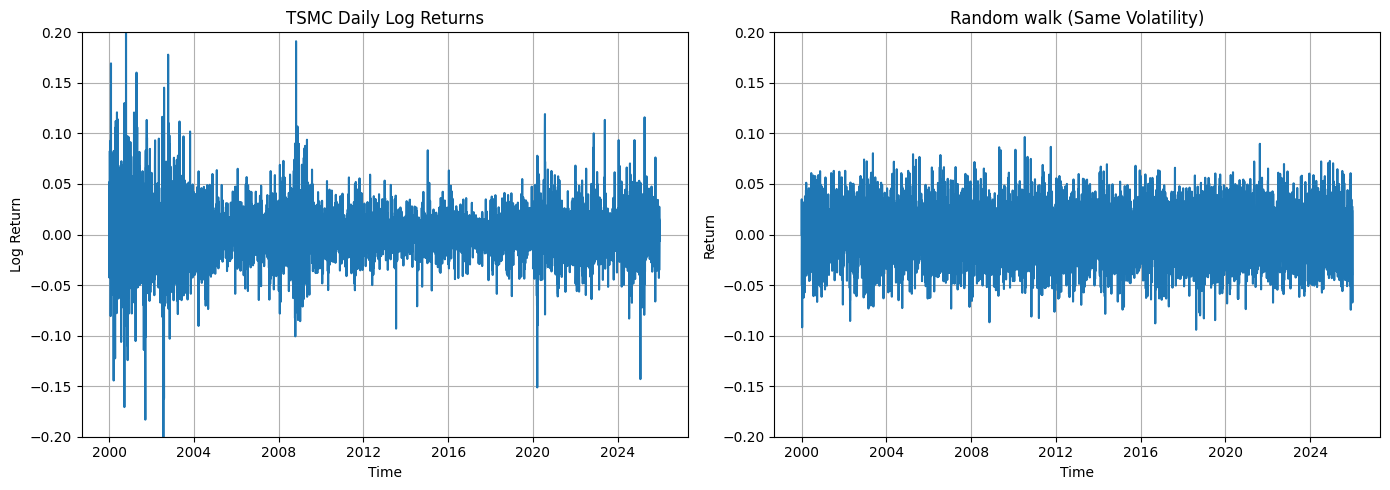

In [ ]:
tsm["r"] = np.log(tsm["Adj Close"] / tsm["Adj Close"].shift(1))
tsm = tsm.dropna()
N = len(tsm["r"])


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# TSMC Returns
axes[0].plot(tsm.index, tsm["r"])
axes[0].set_title("TSMC Daily Log Returns")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Log Return")
axes[0].set_ylim(-0.20, 0.20)
axes[0].grid(True)

# random walk returns with the same parameters
axes[1].plot(tsm.index, noise)
axes[1].set_title("Random walk (Same Volatility)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Return")
axes[1].set_ylim(-0.20, 0.20)
axes[1].grid(True)

plt.tight_layout()
plt.show()

- So clearly, we can't conclude that the TSMC return data behaves like a random walk for a example but why?

1. We can observe how the TSMC data do not follow a stationary process, the distribution changes over time!

2. Also, without running any statistic test we can see how there are spikes and outliers, something not proper for a generalized random walk 

- So it is really unlikely to model a time series only using a single model with fixed parametrs over time, that model might fit much better if maybe we combine different elements

## Model estimation and identification for TSMC 

mean: 0.0005454350194510195
std: 0.025800358096498197


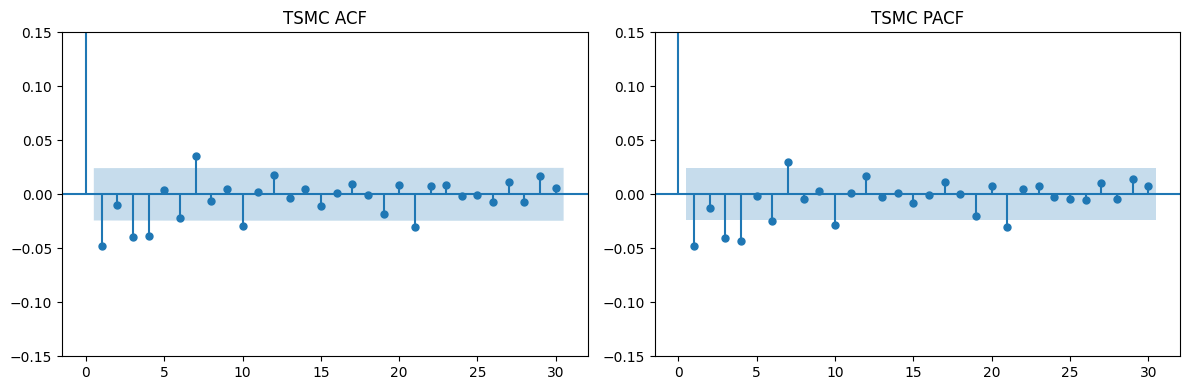

In [85]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

print("mean:", tsm["r"].mean())
print("std:", tsm["r"].std())

# ACF
plot_acf(tsm["r"], lags=30, ax=axes[0])
axes[0].set_title("TSMC ACF")
axes[0].set_ylim(-0.15, 0.15)

# PACF
plot_pacf(tsm["r"], lags=30, ax=axes[1], method="ywm")
axes[1].set_title("TSMC PACF")
axes[1].set_ylim(-0.15, 0.15)
plt.tight_layout()
plt.show()

- Real data (TSMC log retusn) do not show any concrete MA or MA behavior , we can observe how some previous observations have some linear effect on present observations but not any cutoff or decaying

Lets try to fit AR, MA and ARIMA models but:

1. What would be the best parameteres in those cases?
2. What is the significance of those parameters?
3. Do we think that the time seriesi s starionary?

In [92]:
AR_tsmc = ARIMA(r, order=(4, 0, 0))
AR_tsmc_results = AR_tsmc.fit()
print("AR(4) results:")
print(AR_tsmc_results.summary())

MA_tsmc = ARIMA(r, order=(0, 0, 4))
MA_tsmc_results = MA_tsmc.fit()
print("MA(4) results:")
print(MA_tsmc_results.summary())

ARIMA_tsmc = ARIMA(r, order=(4, 0, 2))
ARIMA_tsmc_results = ARIMA_tsmc.fit()
print("ARIMA(4,0,2) results:")
print(ARIMA_tsmc_results.summary())

AR(4) results:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(4, 0, 0)   Log Likelihood               -1523.442
Date:                Tue, 23 Jun 2026   AIC                           3058.885
Time:                        10:21:29   BIC                           3088.331
Sample:                             0   HQIC                          3070.077
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0455      0.043      1.055      0.291      -0.039       0.130
ar.L1         -0.1084      0.031     -3.479      0.001      -0.169      -0.047
ar.L2          0.3565      0.030     

- We could not observe any common behavior of a AR, MA or ARIMA process in the PACF - ACF plots, but when we play with the parameteres and fit some models we can see how:

1. The AR(4) model seem to be the best fit, all the coeficients are significant and has the lowest AIC
2. The MA(2) model would suggest that the first two previous shocks present significant effect on the model
3. The ARIMA(4,0,2) model only has 1 significant value, the fourth AR lag, it would suggest that is overfitting the series
4. All models suggest that we do not have enough prove to contradict that the residuals behave like white noise

In [93]:
AR1 = ARIMA(r, order=(1, 0, 0)).fit()
AR2 = ARIMA(r, order=(2, 0, 0)).fit()
AR3 = ARIMA(r, order=(3, 0, 0)).fit()
AR4 = ARIMA(r, order=(4, 0, 0)).fit()

print(AR1.aic)
print(AR2.aic)
print(AR3.aic)
print(AR4.aic)

3181.907163464324
3090.016053812962
3080.1348116134545
3058.8848368609433
